# Error Normalized Distance Simulations
A first study of the ideal error normalized distance distributions was done in 'crossmatch_analysis.ipynb'

In this notebook, we include all code and plots to study how error normalized distributions should behave, and change under varying distances and covariances

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# Import own modules
import sys
# ESA pc
sys.path.append('/home/rkievit/masterproject/masterproject/src')
# Home PC
sys.path.append('F:\\OneDrive - Telecom Business Transformers BV\\School\\Uni\\MSc Year 2\\Master Research Project\\Project\\masterproject\\src')
# Uni PC
sys.path.append('/net/student36/data2/kievit/Master Project/masterproject/src')

from plotting_functions import set_styles
from astrometry_equations import rayleigh, compute_error_normalized_distance
set_styles()

# Simulate Samples

In [4]:
# MOVE SOMEWHERE ELSE
def simulate_error_normalized_distance(dist_mean1, dist_mean2, unc1, unc2, num_samples, method='full', coordinates='cartesian', units='rad'):
    """Simulates num_samples pairs of data points and computes the error normalized distances between them

    TODO: Expand documentation, expand flexibility of code"""

    if len(dist_mean1) == 2:
        # Should check here if we have just 2 vals, or an array of vals
        pass

    if len(unc1) == 3:
        # Check here if all points have same spread, or if it varies
        sigma_x1, sigma_y1, sigma_xy1 = unc1
        sigma_x2, sigma_y2, sigma_xy2 = unc2

        cov1 = [[sigma_x1, sigma_xy1], [sigma_xy1, sigma_y1]]
        cov2 = [[sigma_x2, sigma_xy2], [sigma_xy2, sigma_y2]]

    pos1 = np.random.multivariate_normal(dist_mean1, cov1, num_samples)
    pos2 = np.random.multivariate_normal(dist_mean2, cov2, num_samples)

    unc1 = np.array([np.full(num_samples, sigma_x1), np.full(num_samples, sigma_y1), np.full(num_samples, sigma_xy1)]).T
    unc2 = np.array([np.full(num_samples, sigma_x2), np.full(num_samples, sigma_y2), np.full(num_samples, sigma_xy2)]).T

    en_dist = compute_error_normalized_distance(pos1, pos2, unc1, unc2, method=method, coordinates=coordinates, unit=units)

    return en_dist

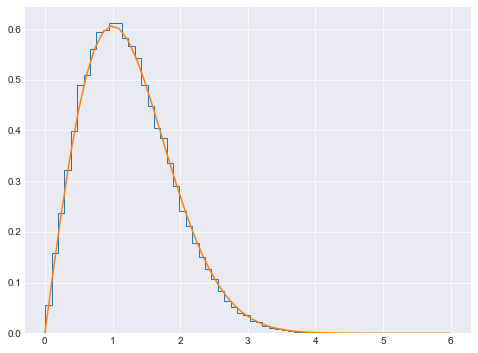

In [7]:
num_samples = 100000
dist_mean1 = [0,0]
dist_mean2 = [0.1,0]
unc1 = [8, 6, 0.4]
unc2 = [3, 4, -0.1]

error_normalized_distances = simulate_error_normalized_distance(dist_mean1, dist_mean2, unc1, unc2, num_samples, method='full')

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot()

ax.hist(error_normalized_distances, bins=50, histtype='step', density=True)
x = np.linspace(0,6,50)
ax.plot(x, rayleigh(x,1))
plt.show()

# Simulate Pairs

In [93]:
# CODE FROM A.G.A. Brown
def error_ellipses(mu, covmat, sigma_levels, **kwargs):
    """
    Given a covariance matrix for a 2D Normal distribution calculate the uncertainty-ellipses and return
    matplotlib patches for plotting them.
    Parameters
    ----------
    mu : float array
        Mean of Normal distribution (2-vector)
    covmat : float array
        Covariance matrix stored as [sigma_x^2, sigma_y^2, sigma_xy]
    sigma_levels : float or 1-D array
        Equivalent n-sigma levels to draw
    Returns
    -------
    patches : list of matplotlib.patches.Ellipse
        List of matplotlib.patches.Ellipse objects
    Other parameters
    ----------------
    **kwargs :
        Extra arguments for matplotlib.patches.Ellipse
    """
    import matplotlib as mpl
    from scipy.special import erf

    sigmaLevels2D = -2.0 * np.log(
        1.0 - erf(np.array([sigma_levels]).flatten() / np.sqrt(2.0))
    )

    eigvalmax = 0.5 * (
        covmat[0]
        + covmat[1]
        + np.sqrt((covmat[0] - covmat[1]) ** 2 + 4 * covmat[2] ** 2)
    )
    eigvalmin = 0.5 * (
        covmat[0]
        + covmat[1]
        - np.sqrt((covmat[0] - covmat[1]) ** 2 + 4 * covmat[2] ** 2)
    )
    angle = np.arctan2((covmat[0] - eigvalmax), -covmat[2]) / np.pi * 180
    errEllipses = []
    for csqr in sigmaLevels2D:
        errEllipses.append(
            mpl.patches.Ellipse(
                mu,
                2 * np.sqrt(csqr * eigvalmax),
                2 * np.sqrt(csqr * eigvalmin),
                angle=angle,
                **kwargs
            )
        )

    return errEllipses

# MOVE THIS TO ASTROMETRY EQUATIONS
def compute_error_normalized_distance(pos1, pos2, unc1, unc2, method='full', coordinates='spherical', unit='mas'):
    """Calculates the 2-dimensional error normalized distance, D, between two objects with uncertainties,
    following a variety of possible methods as listed below.

        None:        No error normalization performed, this function just returns the distance between x,y
        Simple:      Uncertainties are approximated as a circle with radius sigma^2 = 0.5(sigma_x^2 + sigma_y^2)
        Directional: Computes D separately in the x and y directions first, and then combines using Pythagoras
        Full:        Utilizes the full covariance matrix and distance vector

    Inputs:
        pos1: Nx2 array containing the [x,y] coordinates of the first object
        pos2: See above, but for the second object
        unc1: Nx3 array containing all (co)variance terms of object 1 necessary for the chosen methods.
              List as [sigma_x^2, sigma_y^2, sigma_xy], not given values are treated as 0. # Maybe this should be np.nan?
        unc2: See above, but for the second object
        method: Choose from none, simple, directional, full. For descriptions see above
        coordinates: If set to spherical, transforms x |-> x cos(y) for distance calculation to account for spherical effects near poles
        unit: Check to ensure trigonometry is performed properly in the case of spherical coordinates

    Outputs:
        error_norm_distances: array of size N describing the error normalized distance for all provided object pairs
    """

    # Bad inputs check
    if not method in ['none', 'simple', 'directional', 'full']:
        raise ValueError(f'method {method} not implemented in this function')
    if not ((pos1.shape == pos2.shape) and (unc1.shape == unc2.shape)):
        raise ValueError(f'position or uncertainty arrays are of different shapes')

    if len(pos1.shape) == 1: # Then N=1
        x1, y1 = pos1
        sigma_x1, sigma_y1, sigma_xy1 = unc1
        x2, y2 = pos2
        sigma_x2, sigma_y2, sigma_xy2 = unc2
    elif len(pos1.shape) == 2:
        # Extract all columns, and store in separate variables
        x1, y1 = pos1[:,0], pos1[:,1]
        sigma_x1, sigma_y1, sigma_xy1 = unc1[:,0], unc1[:,1], unc1[:,2]
        x2, y2 = pos2[:,0], pos2[:,1]
        sigma_x2, sigma_y2, sigma_xy2 = unc2[:,0], unc2[:,1], unc2[:,2]
    else:
        raise ValueError(f'Array with dimension {len(pos1.shape)} not supported')

    # Transform x to x cos(y) to account for spherical effects
    if coordinates == 'spherical':
        if unit == 'rad':
            y1_rad, y2_rad = y1, y2
        elif unit == 'deg':
            y1_rad, y2_rad = np.radians(y1), np.radians(y2)
        elif unit == 'mas':
            y1_rad, y2_rad = np.radians(y1/3.6e6), np.radians(y2/3.6e6) # 3600 * 1e3 = 3.6e6
        else:
            raise NotImplementedError(f'unit {unit} not recognized')
        x1_corr = x1 * np.cos(y1_rad)
        x2_corr = x2 * np.cos(y2_rad)
    else:
        x1_corr = x1
        x2_corr = x2

    # Only method that computes D not from the combined distance
    if method == 'directional':
        total_x_unc = np.sqrt(sigma_x1 + sigma_x2)
        total_y_unc = np.sqrt(sigma_y1 + sigma_y2)

        x_dist_norm = (x1_corr - x2_corr)/total_x_unc
        y_dist_norm = (y1 - y2)/total_y_unc

        return np.sqrt(x_dist_norm**2. + y_dist_norm**2.)

    elif method == 'full':
        # chi^2 = v^T S^-1 v
        # Setup distance vector and covariance matrix
        if len(pos1.shape) > 1:
            delta_distance = np.stack(((x1_corr-x2_corr), (y1-y2)), axis=1)

            cov_mat_top = np.stack((sigma_x1 + sigma_x2, sigma_xy1 * np.sqrt(sigma_x1*sigma_y1) + sigma_xy2 * np.sqrt(sigma_x2*sigma_y2)), axis=1)
            cov_mat_bot = np.stack((sigma_xy1 * np.sqrt(sigma_x1*sigma_y1) + sigma_xy2 * np.sqrt(sigma_x2*sigma_y2), sigma_y1 + sigma_y2), axis=1)

            cov_matrix = np.stack((cov_mat_top, cov_mat_bot), axis=1)
        else:
            delta_distance = np.array([x1_corr - x2_corr, y1 - y2])
            #print(f'v:{delta_distance}')
            cov_matrix = np.array([[sigma_x1+sigma_x2, sigma_xy1*np.sqrt(sigma_x1*sigma_y1)+sigma_xy2*np.sqrt(sigma_x2*sigma_y2)], [sigma_xy1*np.sqrt(sigma_x1*sigma_y1)+sigma_xy2*np.sqrt(sigma_x2*sigma_y2), sigma_y1+sigma_y2]])
            #print(f'S: {cov_matrix}')
            #cov_matrix = np.array([[sigma_x1+sigma_x2, sigma_xy1+sigma_xy2], [sigma_xy1+sigma_xy2, sigma_y1+sigma_y2]])
        cov_matrix_inverse = np.linalg.inv(cov_matrix) # Inverts each of the N matrices individually
        #print(f'S^-1: {cov_matrix_inverse}')

        # Calculate chi squared
        if len(pos1.shape) > 1:
            # https://stackoverflow.com/questions/35894631/multiply-array-of-vectors-with-array-of-matrices-return-array-of-vectors
            # Figure out how einsum exactly works (and better name?)
            vt_Sinverse = np.einsum('ij,ijk->ik', delta_distance, cov_matrix_inverse)
            chi_squared = np.einsum('ij,ij->i', vt_Sinverse, delta_distance)
        else:
            vt_Sinverse = np.matmul(delta_distance, cov_matrix_inverse)
            chi_squared = np.matmul(vt_Sinverse, delta_distance)
            #print(f'chi_squared {chi_squared}')

        return np.sqrt(np.abs(chi_squared))

    # Start by computing distances
    distances = np.sqrt((x1_corr - x2_corr)**2. + (y1 - y2)**2.)

    if method == 'none':
        return distances
    elif method == 'simple':
        avg_unc1_sq = 0.5*(sigma_x1 + sigma_y1)
        avg_unc2_sq = 0.5*(sigma_x2 + sigma_y2)
        combined_unc = np.sqrt(avg_unc1_sq + avg_unc2_sq)

        return distances/combined_unc

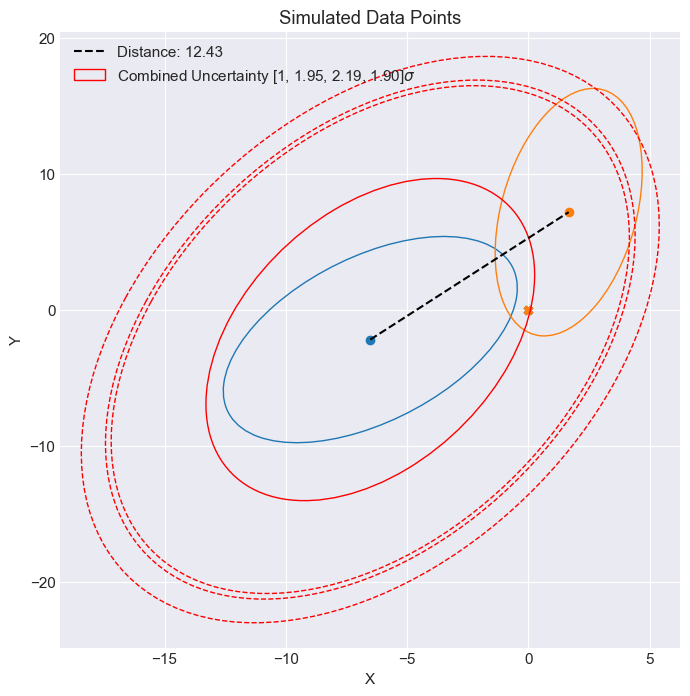

In [74]:
# Simulate two points with the same mean, at some distance from each other.
mean1 = np.array([0,0])
mean2 = mean1

unc1 = np.array([16, 25, 10]) # sigma_x^2, sigma_y^2, sigma_xy
unc2 = np.array([4, 36, 4])

cov1 = [[unc1[0], unc1[2]], [unc1[2], unc1[1]]]
cov2 = [[unc2[0], unc2[2]], [unc2[2], unc2[1]]]

# sigma's not squared?
#cov1 = [[np.sqrt(unc1[0]), unc1[2]], [unc1[2], np.sqrt(unc1[1])]]
#cov2 = [[np.sqrt(unc2[0]), unc2[2]], [unc2[2], np.sqrt(unc2[1])]]

# Sample two points from this distribution
pos1 = np.random.multivariate_normal(mean1, cov1, 1)[0]
pos2 = np.random.multivariate_normal(mean2, cov2, 1)[0]

# Compute distance and error normalized distances
distance = compute_error_normalized_distance(pos1, pos2, unc1, unc2, method='none', coordinates='cartesian')
D_simple = compute_error_normalized_distance(pos1, pos2, unc1, unc2, method='simple', coordinates='cartesian')
D_directional = compute_error_normalized_distance(pos1, pos2, unc1, unc2, method='directional', coordinates='cartesian')
D_full = compute_error_normalized_distance(pos1, pos2, unc1, unc2, method='full', coordinates='cartesian')



# Draw error ellipses individually using agapylib
ellipse_kwargs = {
    'fc': None,
    'fill': False
}
ellipse1 = error_ellipses(pos1, unc1, 1, **ellipse_kwargs, ec='C0')
ellipse2 = error_ellipses(pos2, unc2, 1, **ellipse_kwargs, ec='C1')
ellipse_combined = error_ellipses(pos1, unc1+unc2, 1, **ellipse_kwargs, ec='red', label=rf'Combined Uncertainty [1, {D_simple:.2f}, {D_directional:.2f}, {D_full:.2f}]$\sigma$')
ellipse_combined_D = error_ellipses(pos1, unc1+unc2, [D_simple, D_directional, D_full], **ellipse_kwargs, ec='red', ls='--')#$, label=rf'Combined Uncertainty {D_full:.2f}$\sigma$')

# Plot everything
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot()

ax.scatter(mean1[0], mean1[1], c='C0', marker='X')
ax.scatter(mean2[0], mean2[1], c='C1', marker='X')

ax.scatter(pos1[0], pos1[1], c='C0')
ax.scatter(pos2[0], pos2[1], c='C1')
ax.plot([pos1[0], pos2[0]], [pos1[1], pos2[1]], c='black', ls='--', label=f'Distance: {distance:.2f}')

# Plot ellipses
ax.add_patch(ellipse1[0])
ax.add_patch(ellipse2[0])

ax.add_patch(ellipse_combined[0])
for i in range(len(ellipse_combined_D)):
    ax.add_patch(ellipse_combined_D[i])

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_title(f'Simulated Data Points')

plt.legend()
plt.show()

r = 1.0

r = 0.7220713196321277


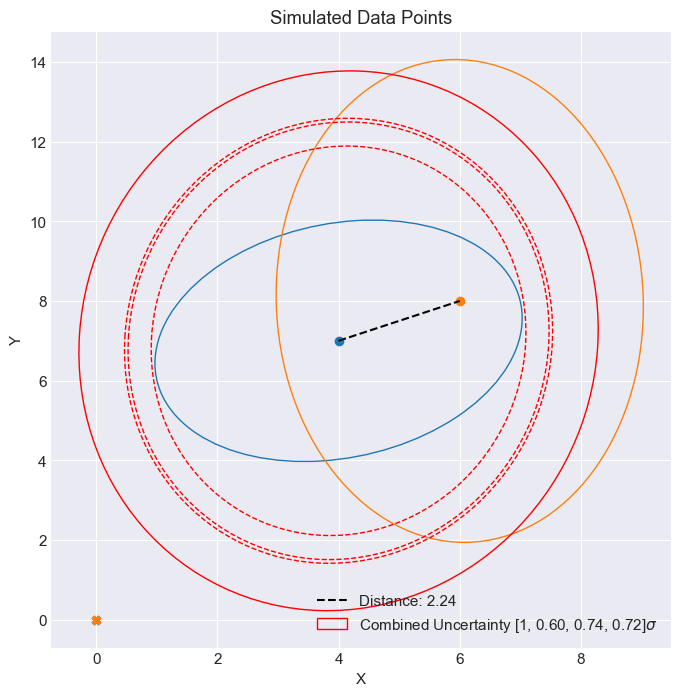

In [92]:
# Test calculations. See notebook
# Remember, unc should be inserted as [sigma_x^2, sigma_y^2, sigma_xy]
# 1.
pos1, pos2 = np.array([2,0]), np.array([0,1])
unc1, unc2 = np.array([1,4,0]), np.array([4, 1, 0])
print(f"r = {compute_error_normalized_distance(pos1, pos2, unc1, unc2, method='full', coordinates='cartesian')}")
print('')
#2.
pos1, pos2 = np.array([4,7]), np.array([6,8])
unc1, unc2 = np.array([4,4,0.75]), np.array([4,16,-0.2])
print(f"r = {compute_error_normalized_distance(pos1, pos2, unc1, unc2, method='full', coordinates='cartesian')}")

# Compute distance and error normalized distances
distance = compute_error_normalized_distance(pos1, pos2, unc1, unc2, method='none', coordinates='cartesian')
D_simple = compute_error_normalized_distance(pos1, pos2, unc1, unc2, method='simple', coordinates='cartesian')
D_directional = compute_error_normalized_distance(pos1, pos2, unc1, unc2, method='directional', coordinates='cartesian')
D_full = compute_error_normalized_distance(pos1, pos2, unc1, unc2, method='full', coordinates='cartesian')



# Draw error ellipses individually using agapylib
ellipse_kwargs = {
    'fc': None,
    'fill': False
}
ellipse1 = error_ellipses(pos1, unc1, 1, **ellipse_kwargs, ec='C0')
ellipse2 = error_ellipses(pos2, unc2, 1, **ellipse_kwargs, ec='C1')
ellipse_combined = error_ellipses(pos1, unc1+unc2, 1, **ellipse_kwargs, ec='red', label=rf'Combined Uncertainty [1, {D_simple:.2f}, {D_directional:.2f}, {D_full:.2f}]$\sigma$')
ellipse_combined_D = error_ellipses(pos1, unc1+unc2, [D_simple, D_directional, D_full], **ellipse_kwargs, ec='red', ls='--')#$, label=rf'Combined Uncertainty {D_full:.2f}$\sigma$')

# Plot everything
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot()

ax.scatter(mean1[0], mean1[1], c='C0', marker='X')
ax.scatter(mean2[0], mean2[1], c='C1', marker='X')

ax.scatter(pos1[0], pos1[1], c='C0')
ax.scatter(pos2[0], pos2[1], c='C1')
ax.plot([pos1[0], pos2[0]], [pos1[1], pos2[1]], c='black', ls='--', label=f'Distance: {distance:.2f}')

# Plot ellipses
ax.add_patch(ellipse1[0])
ax.add_patch(ellipse2[0])

ax.add_patch(ellipse_combined[0])
for i in range(len(ellipse_combined_D)):
    ax.add_patch(ellipse_combined_D[i])

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_title(f'Simulated Data Points')

plt.legend()
plt.savefig('temp')
plt.show()
